# Assignment template

## Business Understanding

In [30]:
import time
import mlxtend
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, KMeans

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

import random

## Data understanding

In [31]:
ruleminingdf = pd.read_csv('datasets/drone_prod_groups.csv', sep=',')
ruleminingdf

,ID,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,...,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,2,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,1,1,1,1,1
2,3,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
3,4,1,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1
4,5,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
99996,99997,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
99997,99998,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
99998,99999,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,1


In [32]:
df = pd.read_csv('datasets/drone_cust_locations.csv', sep=';')

df

,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298
...,...,...,...
5951,5952,832.857394,616.861410
5952,5953,242.734500,490.325092
5953,5954,108.690847,758.833921
5954,5955,803.251074,430.740623


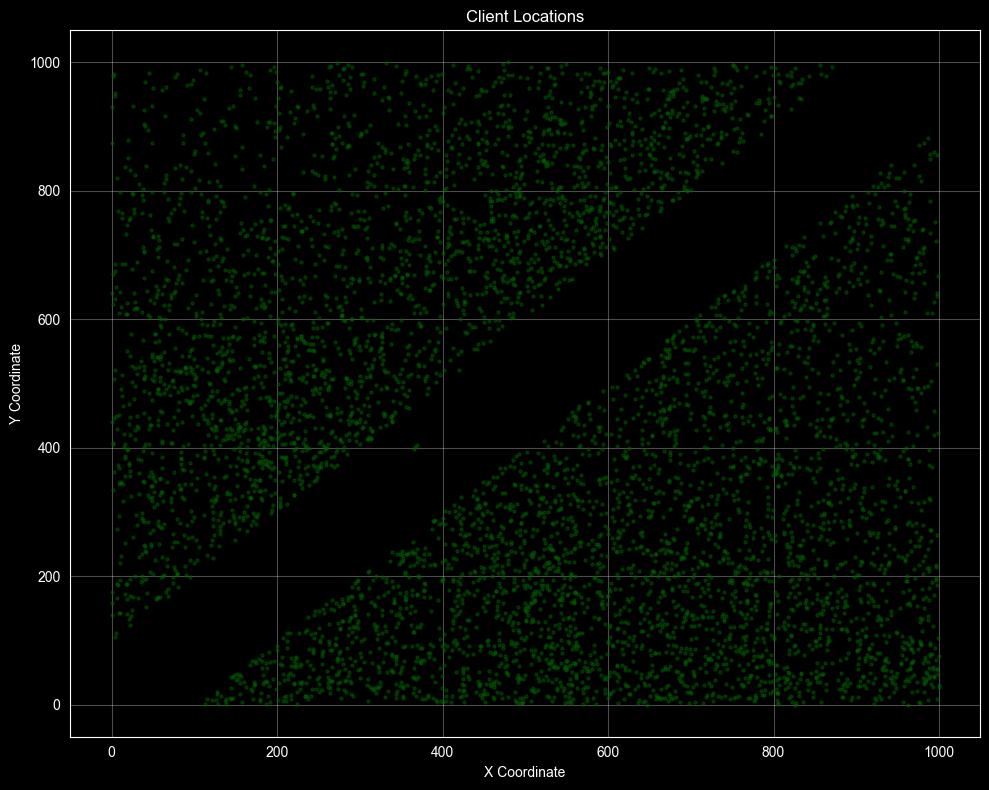

In [33]:
plt.figure(figsize=(10, 10))
plt.scatter(df['x'], df['y'], s=5, alpha=0.4, color='darkgreen')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Client Locations')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Data preparation

In [34]:
#ruleminingdf = ruleminingdf.drop(columns='ID')

# replace NaN values with False
ruleminingdf = ruleminingdf.fillna(False)

# replace 1.0 values with True
ruleminingdf = ruleminingdf.apply(lambda x: x.map(lambda y: True if y == 1.0 else False))
ruleminingdf

,ID,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,...,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,True,False,False,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
1,False,False,True,False,False,False,False,False,False,True,...,False,False,False,False,True,True,True,True,True,True
2,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,True
3,False,True,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,True
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
99996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
99997,False,False,True,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,True,False,False
99998,False,False,True,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,True


In [35]:
depotamount = 3
randomseed = 32392839
cycles = 10
random.seed(randomseed)

## Modeling

In [36]:
frequent_itemsets = apriori(ruleminingdf, min_support=0.1, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.10998,(Prod1)
1,0.13098,( Prod2)
2,0.10459,( Prod5)
3,0.13499,( Prod7)
4,0.16179,( Prod8)
5,0.19853,( Prod9)
6,0.10848,( Prod11)
7,0.15971,( Prod12)
8,0.14557,( Prod14)
9,0.11880,( Prod15)


In [37]:
rulesconfidence = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)

rulesconfidence = rulesconfidence.sort_values(by='confidence', ascending=False)

rulesconfidence

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1,( Prod15),( Prod9),0.11880,0.19853,0.11145,0.938131,4.725388,1.0,0.087865,12.954372,0.894663,0.541335,0.922806,0.749754
3,( Prod20),( Prod19),0.14798,0.20626,0.13476,0.910664,4.415125,1.0,0.104238,8.884845,0.907849,0.613997,0.887449,0.782007
2,( Prod19),( Prod20),0.20626,0.14798,0.13476,0.653350,4.415125,1.0,0.104238,2.457869,0.974508,0.613997,0.593144,0.782007
0,( Prod9),( Prod15),0.19853,0.11880,0.11145,0.561376,4.725388,1.0,0.087865,2.009011,0.983664,0.541335,0.502243,0.749754


In [38]:
ruleslift = association_rules(frequent_itemsets, metric='lift', min_threshold=2)

ruleslift = ruleslift.sort_values(by='lift', ascending=False)

ruleslift

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,( Prod9),( Prod15),0.19853,0.11880,0.11145,0.561376,4.725388,1.0,0.087865,2.009011,0.983664,0.541335,0.502243,0.749754
1,( Prod15),( Prod9),0.11880,0.19853,0.11145,0.938131,4.725388,1.0,0.087865,12.954372,0.894663,0.541335,0.922806,0.749754
2,( Prod19),( Prod20),0.20626,0.14798,0.13476,0.653350,4.415125,1.0,0.104238,2.457869,0.974508,0.613997,0.593144,0.782007
3,( Prod20),( Prod19),0.14798,0.20626,0.13476,0.910664,4.415125,1.0,0.104238,8.884845,0.907849,0.613997,0.887449,0.782007


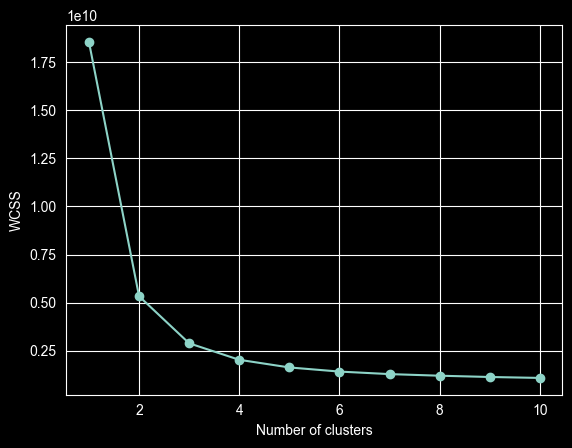

In [39]:
wcss = []
for i in range(1,11):
    model = KMeans(init='random', n_clusters=i, random_state=randomseed).fit(df)
    wcss.append(model.inertia_)
    
plt.plot(range(1,11), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [40]:
meanscoords = df[['x', 'y']].values
aggcoords = df[['x', 'y']].values

kmeans = KMeans(n_clusters=depotamount, random_state=randomseed, n_init=cycles)
kmeans.fit(meanscoords)

depots = kmeans.cluster_centers_

depotdataframe = pd.DataFrame(depots)
#depotdataframe

agg = AgglomerativeClustering(n_clusters=depotamount, linkage='ward')
agg.fit(aggcoords)

aggdepots = np.array([
    aggcoords[agg.labels_ == i].mean(axis=0)
    for i in range(depotamount)
])

aggdepotdataframe = pd.DataFrame(aggdepots)
#aggdepotdataframe

In [41]:
meansdf = df.copy(deep=True)
meansdf['depots']  = kmeans.labels_

#meansdepots.head(10)

aggdf = df.copy(deep=True)
aggdf['depots']  = agg.labels_

#aggdepots.head(10)

## Evaluation

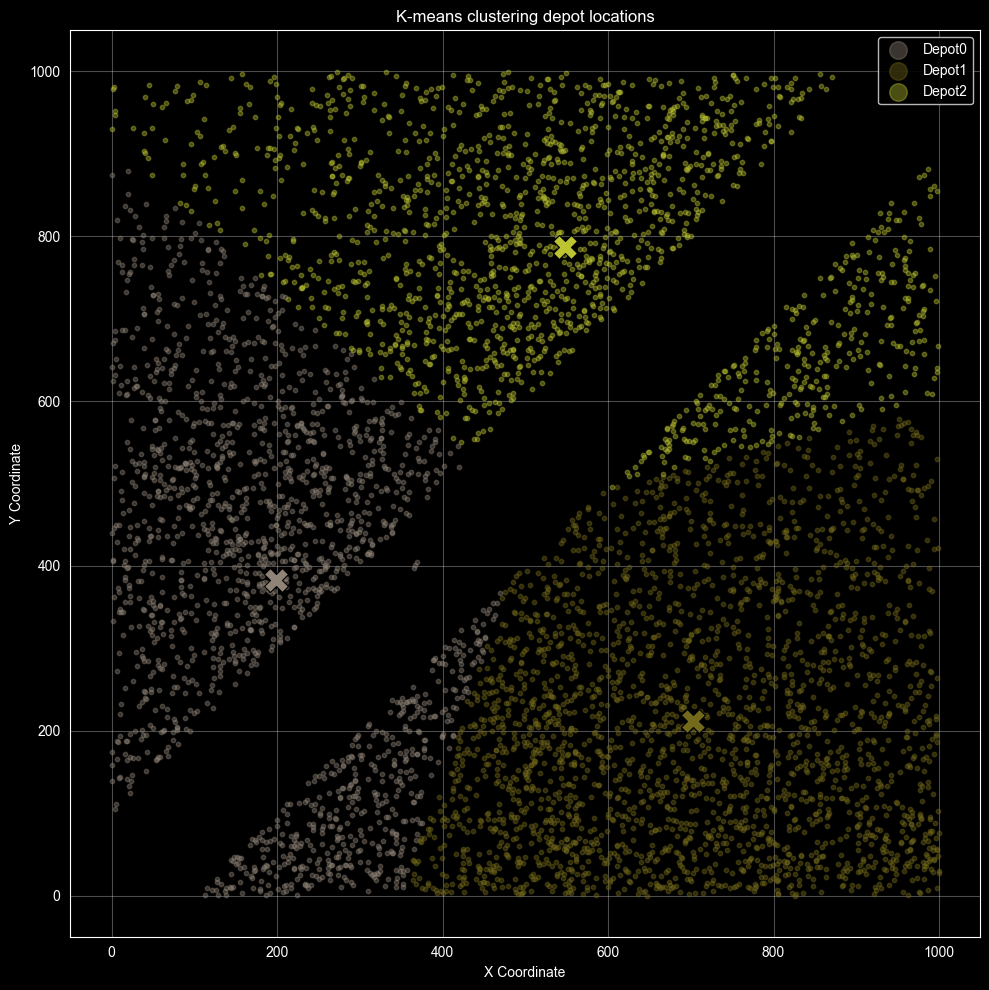

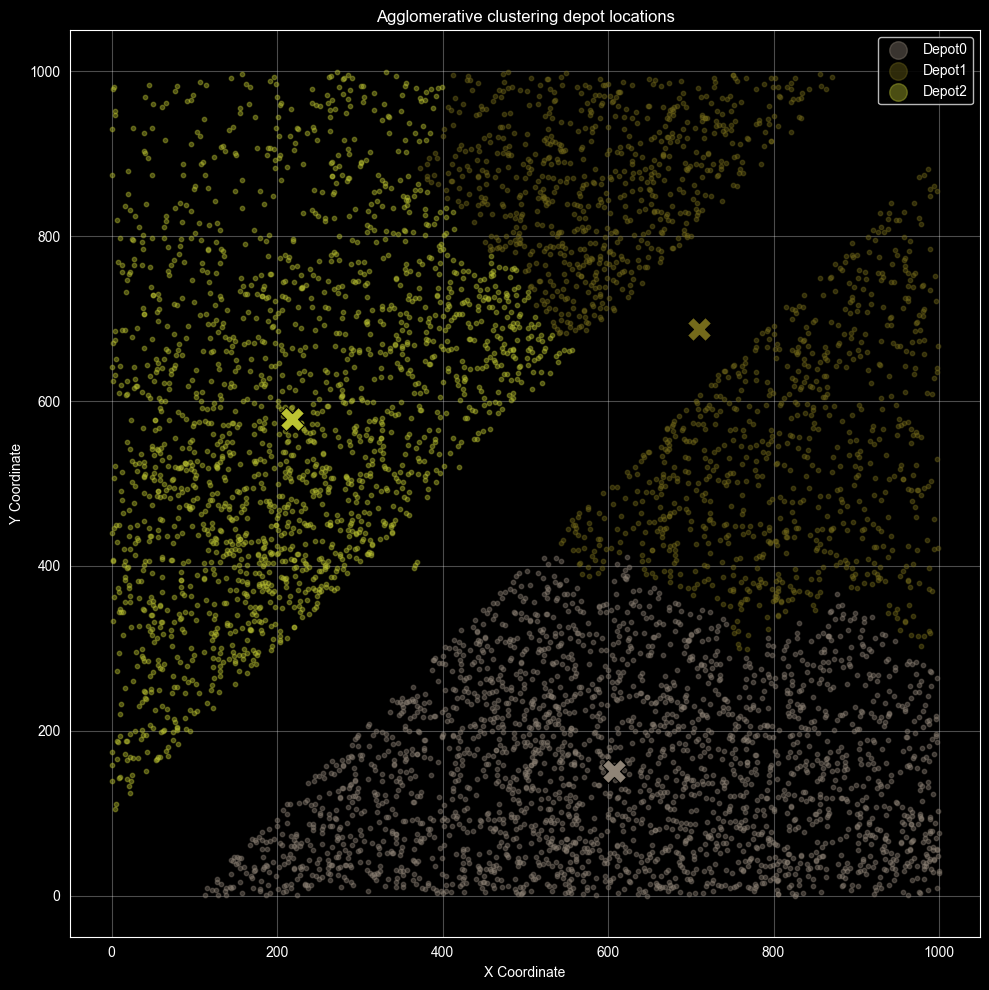

In [42]:
colors = []

for i in range(depotamount):
    color = f"#{random.randrange(0x1000000):06x}"
    colors.append(color)

plt.figure(figsize=(10,10))

##MEANS

for i in range(depotamount):
    cluster = meansdf[meansdf['depots'] == i]
    plt.scatter(cluster['x'], cluster['y'],
                s=10, alpha=0.4, color=colors[i], label="Depot" + str(i))

for i, (cx, cy) in enumerate(depots):
    plt.scatter(cx, cy,
                s=300, color=colors[i], marker='X',
                edgecolors='black', linewidths=0.8, zorder=5)

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.style.use('dark_background')

plt.title('K-means clustering depot locations')
plt.legend(markerscale=4, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##AGG

plt.figure(figsize=(10,10))

for i in range(depotamount):
    cluster = aggdf[aggdf['depots'] == i]
    plt.scatter(cluster['x'], cluster['y'],
                s=10, alpha=0.4, color=colors[i], label="Depot" + str(i))

for i, (cx, cy) in enumerate(aggdepots):
    plt.scatter(cx, cy,
                s=300, color=colors[i], marker='X',
                edgecolors='black', linewidths=0.8, zorder=5)

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.style.use('dark_background')

plt.title('Agglomerative clustering depot locations')
plt.legend(markerscale=4, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Deployment